# 01 – Dataset Exploration (EDA)

**Project:** next-word prediction (keyboard autocomplete) – n-gram vs RNN/LSTM language models trained on Shakespeare.

**Data**
- `data/works/*.txt` – one *raw* file per work (nothing cleaned yet)
- `data/metadata.csv` – `title, slug, category, num_lines, num_words, num_chars`
- `data/baseline/` – WikiText-2 (raw) as a modern-English baseline (downloaded with Hugging Face `datasets` on first run)

**Conventions**
- Every figure is saved to `figures/` (PNG, dpi = 200) and every table to `tables/` (CSV).
- The tokenizer used here is a *simple EDA tokenizer* (lowercase + regex). It is **not** the preprocessing pipeline of the project; that is a later, separate phase.
- Seed = 42 everywhere.

In [1]:
import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from IPython.display import display

DATA = Path("data")
WORKS_DIR = DATA / "works"
BASELINE_DIR = DATA / "baseline"
FIG_DIR = Path("figures")
TAB_DIR = Path("tables")
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(exist_ok=True)

SEED = 42
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

CAT_ORDER = ["Comedy", "Tragedy", "History", "Romance", "Poetry"]
# colour-blind-friendly (Okabe-Ito) palette
CAT_COLORS = {"Comedy": "#E69F00", "Tragedy": "#D55E00", "History": "#0072B2",
              "Romance": "#009E73", "Poetry": "#CC79A7"}


def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved figure -> {path}")


def save_table(df, name, index=False):
    path = TAB_DIR / name
    df.to_csv(path, index=index, encoding="utf-8")
    print(f"saved table  -> {path}")


def pretty(title):
    # "ALL'S WELL ..." -> "All's Well ..."
    t = title.title().replace("\u2019", "'")
    return re.sub(r"'S\b", "'s", t)


# ---- simple EDA tokenizer: lowercase, straight apostrophes, keep inner apostrophes
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)*")


def normalize_apostrophes(text):
    return text.replace("\u2019", "'").replace("\u2018", "'")


def tokenize(text):
    return TOKEN_RE.findall(normalize_apostrophes(text).lower())


# ---- stopwords (NLTK English) + archaic additions used for the "no stopwords" views
try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)
STOP = set(stopwords.words("english"))
ARCHAIC_STOP = {"thou", "thee", "thy", "thine", "hath", "doth", "art"}
STOP_ALL = STOP | ARCHAIC_STOP

# ---- patterns for raw-text structure (used in sections 6 and 8)
HEADER_RE = re.compile(r"^\s*(ACT|SCENE)\s+[IVXL]+\b")
SPEAKER_RE = re.compile(r"^\s*([A-Z][A-Z'\u2019\- ]*[A-Z]|[A-Z])\.(?:\s|$)")
STAGE_RE = re.compile(r"^\s*(Enter|Exit|Exeunt|Re-enter)\b")
BRACKET_RE = re.compile(r"\[[^\]]*\]")
STAGE_WORDS = {"enter", "exit", "exeunt", "act", "scene"}


def structural_part(line):
    # the part of a raw line that is play *structure* (not spoken text): ACT/SCENE header,
    # all-caps speaker tag, or stage direction. Returns "" for ordinary verse/prose lines.
    if HEADER_RE.match(line):
        return line
    if STAGE_RE.match(line) or BRACKET_RE.search(line):
        return line
    m = SPEAKER_RE.match(line)
    return m.group(1) if m else ""


meta = pd.read_csv(DATA / "metadata.csv", encoding="utf-8")
texts = {s: (WORKS_DIR / f"{s}.txt").read_text(encoding="utf-8") for s in meta["slug"]}
print(f"loaded {len(texts)} works")
meta.head()

loaded 44 works


,title,slug,category,num_lines,num_words,num_chars
0,THE SONNETS,sonnets,Poetry,2774,17705,98329
1,ALL’S WELL THAT ENDS WELL,all_s_well_that_ends_well,Comedy,4960,24599,134620
2,THE TRAGEDY OF ANTONY AND CLEOPATRA,antony_and_cleopatra,Tragedy,6637,26767,152396
3,AS YOU LIKE IT,as_you_like_it,Comedy,4434,23142,127038
4,THE COMEDY OF ERRORS,errors,Comedy,3197,16213,88329


## 1. Train / validation / test split (done first)

We split **by whole works**, never by lines, so no passage of a play leaks between sets (neighbouring lines are strongly correlated). Targets are ≈ 80 / 10 / 10 by **word count**.

Procedure (seed 42):
1. Poetry (Sonnets + narrative poems) always stays in **train**.
2. Stratification: one randomly chosen Comedy, Tragedy, History and Romance goes to **test**, and another one of each to **validation**. So test and validation each contain every non-poetry category.
3. If a set is still below ~90 % of its word target, random further works are added (never leaving fewer than 2 works of a category in train, and never overshooting the target by more than 15 %).
4. Everything else is train.

In [2]:
rng = random.Random(SEED)
total_words = int(meta["num_words"].sum())
target = {"test": 0.10 * total_words, "val": 0.10 * total_words}
wc = dict(zip(meta["slug"], meta["num_words"]))
cat_of = dict(zip(meta["slug"], meta["category"]))

STRATA = ["Comedy", "Tragedy", "History", "Romance"]          # Poetry stays in train
pool = {c: sorted(meta.loc[meta["category"] == c, "slug"]) for c in STRATA}
for c in STRATA:
    rng.shuffle(pool[c])

split_of, words_in = {}, {"test": 0, "val": 0}
for part in ("test", "val"):                                   # one work per category per set
    for c in STRATA:
        s = pool[c].pop()
        split_of[s] = part
        words_in[part] += wc[s]

leftovers = [s for c in STRATA for s in pool[c]]
rng.shuffle(leftovers)
MIN_TRAIN_PER_CAT = 2
for part in ("test", "val"):                                   # top-up towards the word target
    for s in list(leftovers):
        if words_in[part] >= 0.9 * target[part]:
            break
        if sum(cat_of[x] == cat_of[s] for x in leftovers) <= MIN_TRAIN_PER_CAT:
            continue
        if words_in[part] + wc[s] > 1.15 * target[part]:
            continue
        split_of[s] = part
        words_in[part] += wc[s]
        leftovers.remove(s)
for s in meta["slug"]:
    split_of.setdefault(s, "train")

split_df = meta[["slug", "title", "category"]].copy()
split_df["split"] = split_df["slug"].map(split_of)
split_df["num_words"] = split_df["slug"].map(wc)
split_df = split_df.sort_values(["split", "category", "slug"]).reset_index(drop=True)
split_df.to_csv(DATA / "split.csv", index=False, encoding="utf-8")
print("saved data/split.csv\n")

# sanity checks
test_cats = set(split_df.loc[split_df["split"] == "test", "category"])
assert {"Comedy", "Tragedy", "History", "Romance"} <= test_cats, "test set misses a category"
assert (split_df.loc[split_df["category"] == "Poetry", "split"] == "train").all()

split_summary = (split_df.groupby("split")
                 .agg(num_works=("slug", "count"), num_words=("num_words", "sum")).reindex(["train", "val", "test"]))
split_summary["pct_of_words"] = (100 * split_summary["num_words"] / total_words).round(2)
print("Word count per split:")
for sp, r in split_summary.iterrows():
    print(f"  {sp:<5} {int(r.num_words):>9,} words  ({r.pct_of_words:5.2f} %)  {int(r.num_works)} works")
print(f"  total {total_words:>9,}")
save_table(split_summary, "split_summary.csv", index=True)

cat_split = pd.crosstab(split_df["category"], split_df["split"]).reindex(index=CAT_ORDER, columns=["train", "val", "test"])
display(cat_split)
save_table(cat_split, "split_works_per_category.csv", index=True)
display(split_df.loc[split_df["split"] != "train", ["title", "category", "split", "num_words"]])

saved data/split.csv

Word count per split:
  train   762,312 words  (79.14 %)  36 works
  val     108,313 words  (11.24 %)  4 works
  test     92,615 words  ( 9.61 %)  4 works
  total   963,240
saved table  -> tables\split_summary.csv


split,train,val,test
category,,,
Comedy,10,1,1
Tragedy,9,1,1
History,8,1,1
Romance,3,1,1
Poetry,6,0,0


saved table  -> tables\split_works_per_category.csv


,title,category,split,num_words
0,"TWELFTH NIGHT; OR, WHAT YOU WILL",Comedy,test,21356
1,THE SECOND PART OF KING HENRY THE SIXTH,History,test,26955
2,THE TEMPEST,Romance,test,17537
3,THE TRAGEDY OF ANTONY AND CLEOPATRA,Tragedy,test,26767
40,AS YOU LIKE IT,Comedy,val,23142
41,KING RICHARD THE THIRD,History,val,31389
42,THE WINTER’S TALE,Romance,val,26139
43,TROILUS AND CRESSIDA,Tragedy,val,27643


Test and validation each get one work from every non-poetry category, and train keeps all the poetry. Note that with only 5 Romance plays, test/val are necessarily small samples of that category, so per-category test results should be read with care.

## 2. Corpus overview

In [3]:
dtype_table = pd.DataFrame({
    "column": meta.columns,
    "dtype": meta.dtypes.astype(str).values,
    "n_unique": meta.nunique().values,
    "n_missing": meta.isna().sum().values,
    "example": meta.iloc[0].astype(str).values,
})
display(dtype_table)
save_table(dtype_table, "metadata_dtypes.csv")

overview = pd.DataFrame({
    "metric": ["number of works", "total lines", "total words (whitespace split)", "total characters",
               "average words per work", "median words per work", "average lines per work"],
    "value": [len(meta), int(meta["num_lines"].sum()), int(meta["num_words"].sum()), int(meta["num_chars"].sum()),
              round(meta["num_words"].mean(), 1), float(meta["num_words"].median()), round(meta["num_lines"].mean(), 1)],
})
display(overview)
save_table(overview, "corpus_overview.csv")

,column,dtype,n_unique,n_missing,example
0,title,str,44,0,THE SONNETS
1,slug,str,44,0,sonnets
2,category,str,5,0,Poetry
3,num_lines,int64,44,0,2774
4,num_words,int64,44,0,17705
5,num_chars,int64,44,0,98329


saved table  -> tables\metadata_dtypes.csv


,metric,value
0,number of works,44.0
1,total lines,195785.0
2,total words (whitespace split),963240.0
3,total characters,5357733.0
4,average words per work,21891.8
5,median words per work,22922.5
6,average lines per work,4449.7


saved table  -> tables\corpus_overview.csv


saved figure -> figures\words_per_work_by_category.png


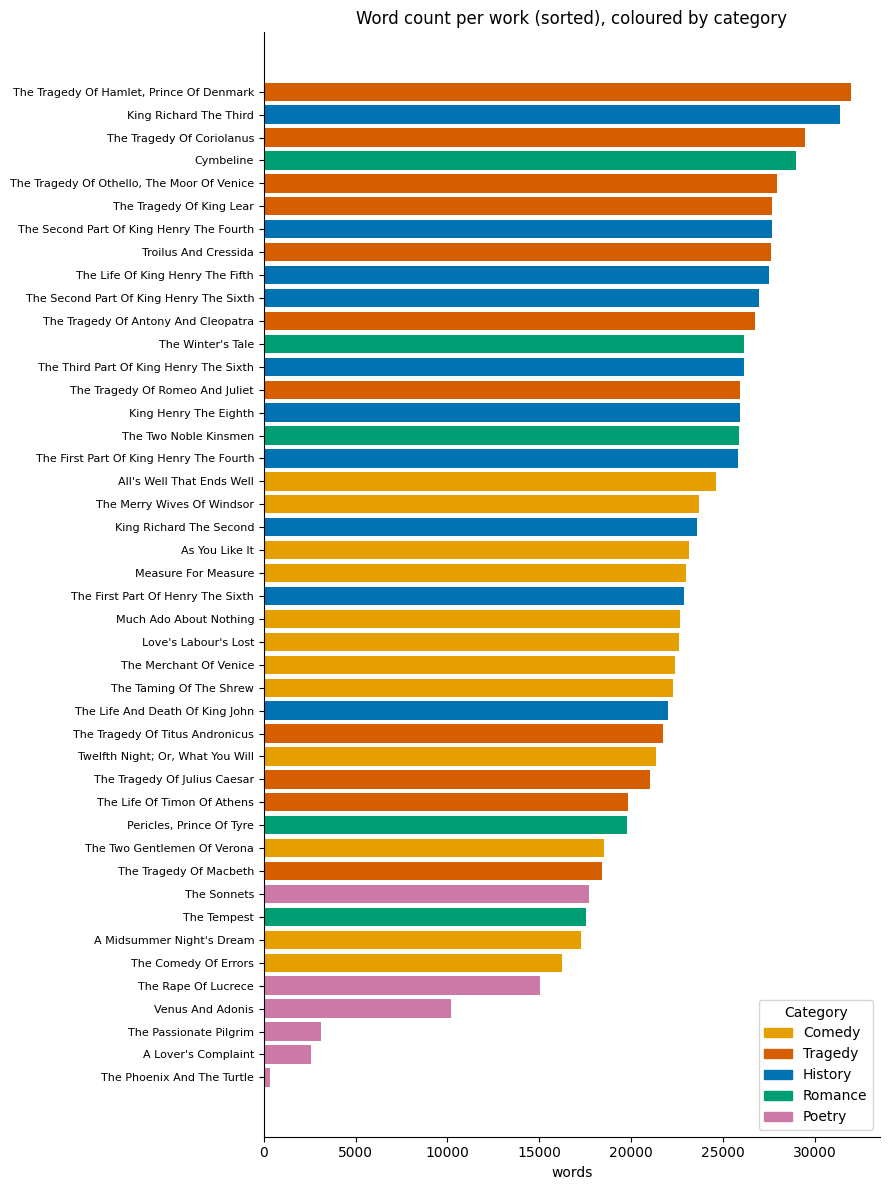

In [4]:
m = meta.sort_values("num_words", ascending=True)
fig, ax = plt.subplots(figsize=(9, 12))
ax.barh([pretty(t) for t in m["title"]], m["num_words"], color=[CAT_COLORS[c] for c in m["category"]])
ax.set_xlabel("words")
ax.set_title("Word count per work (sorted), coloured by category")
handles = [plt.Rectangle((0, 0), 1, 1, color=CAT_COLORS[c]) for c in CAT_ORDER]
ax.legend(handles, CAT_ORDER, title="Category", loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
save_fig(fig, "words_per_work_by_category.png")
plt.show()

,num_works,total_words,avg_words_per_work,pct_of_words
category,,,,
Comedy,12,257700,21475,26.8
Tragedy,11,278359,25305,28.9
History,10,259878,25988,27.0
Romance,5,118323,23665,12.3
Poetry,6,48980,8163,5.1


saved table  -> tables\category_summary.csv
saved figure -> figures\category_words_and_works.png


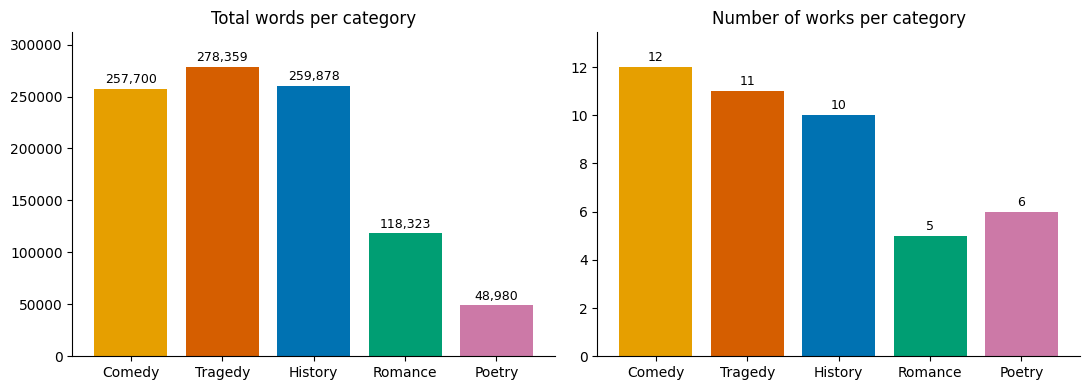

In [5]:
cat_tbl = (meta.groupby("category").agg(num_works=("slug", "count"), total_words=("num_words", "sum"),
                                        avg_words_per_work=("num_words", "mean"))
           .reindex(CAT_ORDER).round(0).astype(int))
cat_tbl["pct_of_words"] = (100 * cat_tbl["total_words"] / cat_tbl["total_words"].sum()).round(1)
display(cat_tbl)
save_table(cat_tbl, "category_summary.csv", index=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cols = [CAT_COLORS[c] for c in cat_tbl.index]
for ax, col, ttl in zip(axes, ["total_words", "num_works"], ["Total words per category", "Number of works per category"]):
    bars = ax.bar(cat_tbl.index, cat_tbl[col], color=cols)
    ax.bar_label(bars, labels=[f"{v:,}" for v in cat_tbl[col]], padding=2, fontsize=9)
    ax.set_title(ttl)
    ax.set_ylim(0, cat_tbl[col].max() * 1.12)
plt.tight_layout()
save_fig(fig, "category_words_and_works.png")
plt.show()

Tragedy, History and Comedy are of similar size (~27 % of the words each). Poetry is only a few percent of the corpus because the poems are short, and Romance is small (5 works). Any claim about "Poetry" or "Romance" language therefore rests on little data.

## 3. Vocabulary statistics

EDA tokenizer: lowercase, curly → straight apostrophes, tokens = `[a-z]+(?:'[a-z]+)*` (so *don't* and *o'er* stay in one piece, digits and other punctuation are dropped). Statistics here use **all 44 works**; train-only vocabulary is used in section 7.

In [6]:
tokens_by_slug = {s: tokenize(t) for s, t in texts.items()}
corpus_counter = Counter()
for toks in tokens_by_slug.values():
    corpus_counter.update(toks)

N = sum(corpus_counter.values())
V = len(corpus_counter)
hapax = sum(1 for c in corpus_counter.values() if c == 1)
vocab_stats = pd.DataFrame({
    "metric": ["tokens", "vocabulary size (types)", "type-token ratio", "hapax legomena (count)", "hapax legomena (% of vocabulary)",
               "hapax legomena (% of tokens)"],
    "value": [N, V, round(V / N, 4), hapax, round(100 * hapax / V, 2), round(100 * hapax / N, 2)],
})
display(vocab_stats)
save_table(vocab_stats, "vocabulary_stats.csv")

,metric,value
0,tokens,968022.0000
1,vocabulary size (types),26909.0000
2,type-token ratio,0.0278
3,hapax legomena (count),10164.0000
4,hapax legomena (% of vocabulary),37.7700
5,hapax legomena (% of tokens),1.0500


saved table  -> tables\vocabulary_stats.csv


### Zipf's law
Rank-frequency plot on log-log axes. A line is fitted by least squares on ranks 1–1000 (the far tail is a staircase of words with identical small counts, which would distort the fit) and extended over the whole range.

fitted log10(freq) = -1.039 * log10(rank) + 5.159   (Zipf exponent ~ 1.04)


saved figure -> figures\zipf_rank_frequency.png


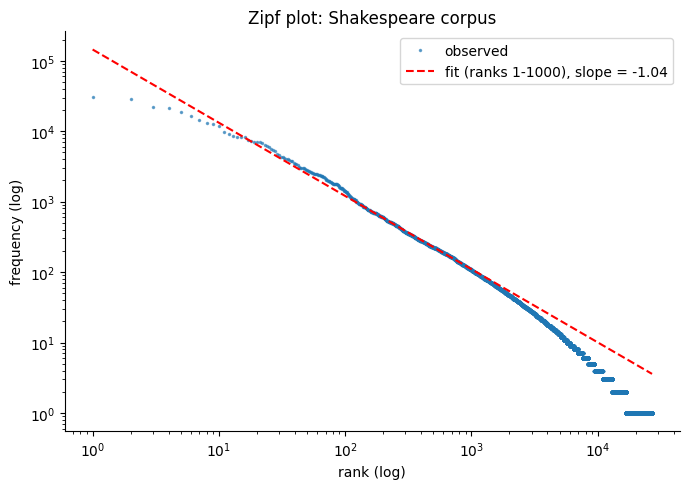

In [7]:
freqs = np.array(sorted(corpus_counter.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)
mask = ranks <= 1000
slope, intercept = np.polyfit(np.log10(ranks[mask]), np.log10(freqs[mask]), 1)
print(f"fitted log10(freq) = {slope:.3f} * log10(rank) + {intercept:.3f}   (Zipf exponent ~ {-slope:.2f})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, freqs, ".", ms=3, alpha=0.6, label="observed")
ax.loglog(ranks, 10 ** (intercept + slope * np.log10(ranks)), "r--", lw=1.5, label=f"fit (ranks 1-1000), slope = {slope:.2f}")
ax.set_xlabel("rank (log)")
ax.set_ylabel("frequency (log)")
ax.set_title("Zipf plot: Shakespeare corpus")
ax.legend()
plt.tight_layout()
save_fig(fig, "zipf_rank_frequency.png")
plt.show()

195,785 lines, 153,416 non-empty; mean 6.31, median 7, 95th pct 13, max 20
saved figure -> figures\line_length_histogram.png


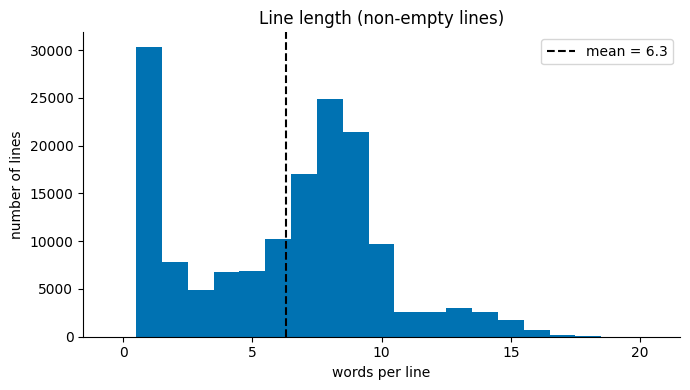

saved table  -> tables\line_length_describe.csv


In [8]:
all_lines = [l for t in texts.values() for l in t.splitlines()]
line_len = np.array([n for n in (len(tokenize(l)) for l in all_lines) if n > 0])
print(f"{len(all_lines):,} lines, {len(line_len):,} non-empty; mean {line_len.mean():.2f}, median {np.median(line_len):.0f}, "
      f"95th pct {np.percentile(line_len, 95):.0f}, max {line_len.max()}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(line_len, bins=np.arange(0, line_len.max() + 2) - 0.5, color="#0072B2")
ax.axvline(line_len.mean(), color="k", ls="--", label=f"mean = {line_len.mean():.1f}")
ax.set_xlabel("words per line")
ax.set_ylabel("number of lines")
ax.set_title("Line length (non-empty lines)")
ax.legend()
plt.tight_layout()
save_fig(fig, "line_length_histogram.png")
plt.show()

pd.Series(line_len).describe().round(2).to_frame("words_per_line").pipe(save_table, "line_length_describe.csv", index=True)

### Frequency buckets (data sparsity)
How many *word types* occur once, 2–5, 6–20 or more than 20 times, and how much of the running text each bucket accounts for. Many rare types that cover little text is exactly the sparsity problem an n-gram model faces.

,bucket,word_types,pct_of_vocabulary,tokens,pct_of_tokens
0,1 (hapax),10164,37.77,10164,1.05
1,2-5,8340,30.99,24823,2.56
2,6-20,4738,17.61,50252,5.19
3,>20,3667,13.63,882783,91.19


saved table  -> tables\frequency_buckets.csv


saved figure -> figures\frequency_buckets.png


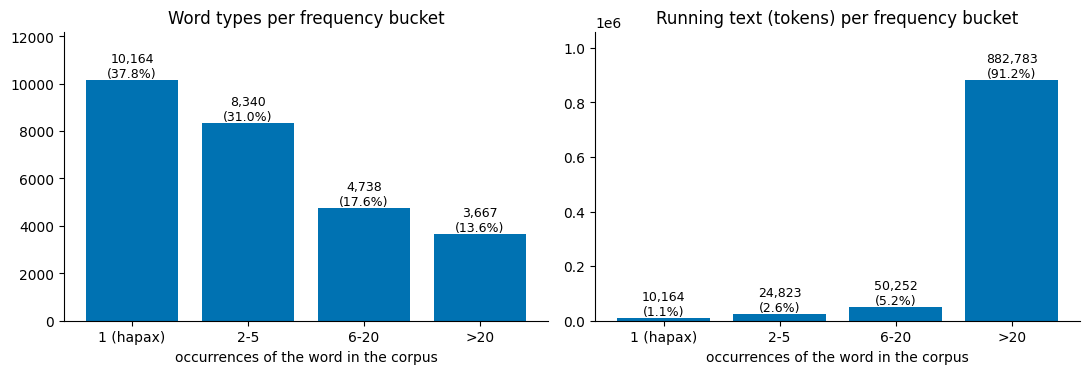

In [9]:
buckets = [("1 (hapax)", lambda c: c == 1), ("2-5", lambda c: 2 <= c <= 5),
           ("6-20", lambda c: 6 <= c <= 20), (">20", lambda c: c > 20)]
rows = []
for name, f in buckets:
    cs = [c for c in corpus_counter.values() if f(c)]
    rows.append({"bucket": name, "word_types": len(cs), "pct_of_vocabulary": round(100 * len(cs) / V, 2),
                 "tokens": sum(cs), "pct_of_tokens": round(100 * sum(cs) / N, 2)})
bucket_df = pd.DataFrame(rows)
display(bucket_df)
save_table(bucket_df, "frequency_buckets.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, pct, ttl in zip(axes, ["word_types", "tokens"], ["pct_of_vocabulary", "pct_of_tokens"],
                             ["Word types per frequency bucket", "Running text (tokens) per frequency bucket"]):
    bars = ax.bar(bucket_df["bucket"], bucket_df[col], color="#0072B2")
    ax.bar_label(bars, labels=[f"{v:,}\n({p:.1f}%)" for v, p in zip(bucket_df[col], bucket_df[pct])], fontsize=9)
    ax.set_title(ttl)
    ax.set_xlabel("occurrences of the word in the corpus")
    ax.set_ylim(0, bucket_df[col].max() * 1.2)
plt.tight_layout()
save_fig(fig, "frequency_buckets.png")
plt.show()

## 4. N-grams

N-grams are counted inside each work's token stream (so they may span line breaks, which is natural for verse, but never span two works). Two views:
- **with stopwords** – everything;
- **without stopwords** – NLTK English stopwords plus the archaic *thou, thee, thy, thine, hath, doth, art* are deleted first, and n-grams are formed from the remaining tokens (so a bigram in this view can join words that were not adjacent in the original text).

saved table  -> tables\top20_unigrams_with_stopwords.csv
saved table  -> tables\top20_bigrams_with_stopwords.csv
saved table  -> tables\top20_trigrams_with_stopwords.csv
saved table  -> tables\top20_unigrams_without_stopwords.csv
saved table  -> tables\top20_bigrams_without_stopwords.csv
saved table  -> tables\top20_trigrams_without_stopwords.csv


saved figure -> figures\top20_ngrams_with_stopwords.png


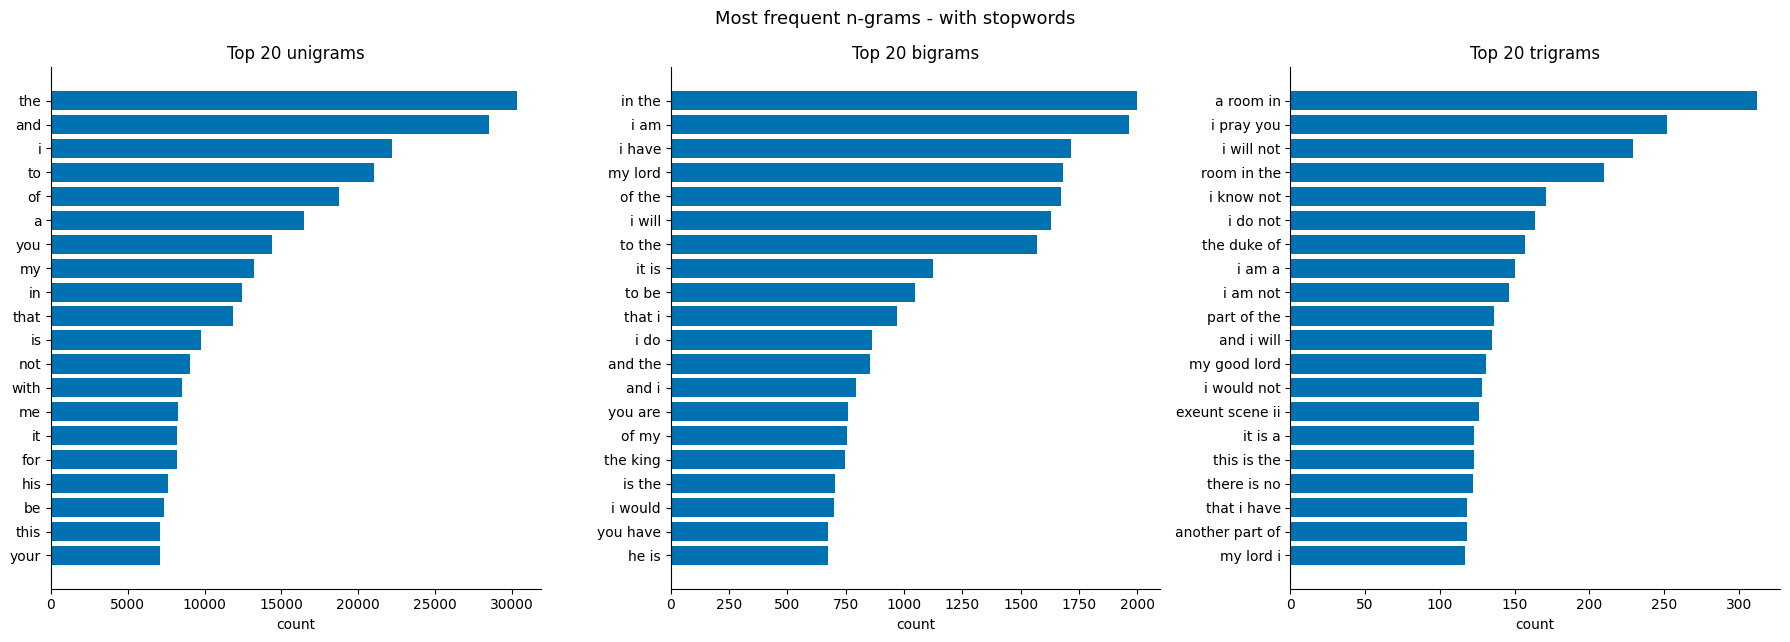

saved figure -> figures\top20_ngrams_without_stopwords.png


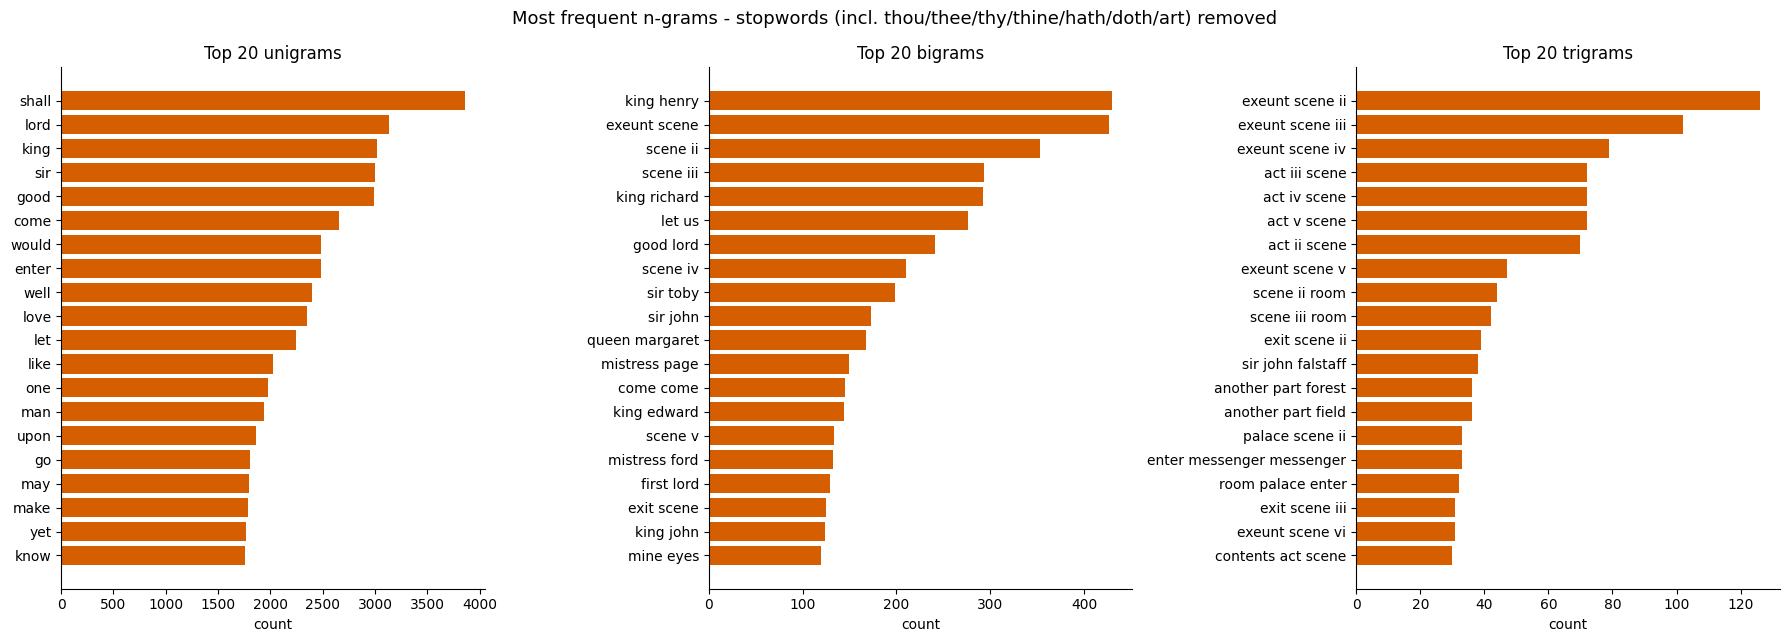

In [10]:
def ngram_counter(token_lists, n):
    c = Counter()
    for toks in token_lists:
        c.update(zip(*(toks[i:] for i in range(n))))
    return c


full_lists = list(tokens_by_slug.values())
filt_lists = [[t for t in toks if t not in STOP_ALL] for toks in full_lists]

ngrams_full = {n: ngram_counter(full_lists, n) for n in (1, 2, 3)}
ngrams_filt = {n: ngram_counter(filt_lists, n) for n in (1, 2, 3)}
NAMES = {1: "unigrams", 2: "bigrams", 3: "trigrams"}


def plot_top(counters, title, fname, color):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    for ax, n in zip(axes, (1, 2, 3)):
        top = counters[n].most_common(20)
        labels = [" ".join(g) for g, _ in top]
        ax.barh(labels[::-1], [c for _, c in top][::-1], color=color)
        ax.set_title(f"Top 20 {NAMES[n]}")
        ax.set_xlabel("count")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()


for view, counters, tag in [("with stopwords", ngrams_full, "with_stopwords"),
                            ("without stopwords", ngrams_filt, "without_stopwords")]:
    for n in (1, 2, 3):
        t = pd.DataFrame([(" ".join(g), c) for g, c in counters[n].most_common(20)], columns=["ngram", "count"])
        t.insert(0, "rank", range(1, 21))
        save_table(t, f"top20_{NAMES[n]}_{tag}.csv")

plot_top(ngrams_full, "Most frequent n-grams - with stopwords", "top20_ngrams_with_stopwords.png", "#0072B2")
plot_top(ngrams_filt, "Most frequent n-grams - stopwords (incl. thou/thee/thy/thine/hath/doth/art) removed",
         "top20_ngrams_without_stopwords.png", "#D55E00")

In [11]:
c4 = ngram_counter(full_lists, 4)
rows = []
for n, c in [(1, ngrams_full[1]), (2, ngrams_full[2]), (3, ngrams_full[3]), (4, c4)]:
    unique = len(c)
    once = sum(1 for v in c.values() if v == 1)
    rows.append({"n": n, "total_ngrams": sum(c.values()), "unique_ngrams": unique,
                 "occurring_once": once, "pct_unique_occurring_once": round(100 * once / unique, 2)})
ngram_stats = pd.DataFrame(rows)
display(ngram_stats)
save_table(ngram_stats, "ngram_uniqueness.csv")
del c4

,n,total_ngrams,unique_ngrams,occurring_once,pct_unique_occurring_once
0,1,968022,26909,10164,37.77
1,2,967978,383680,285166,74.32
2,3,967934,799421,731509,91.50
3,4,967890,934293,913763,97.80


saved table  -> tables\ngram_uniqueness.csv


The share of n-gram *types* that occur exactly once grows rapidly with n: most trigrams and 4-grams are seen a single time, so a plain count-based model has no evidence for them. This is the core reason n-gram models need smoothing/back-off, and a motivation for neural models that generalise across similar contexts.

## 5. Word clouds
Because the raw text still contains speaker names and stage directions (*enter, exeunt, lord, ...*), these will visibly show up. That is intentional at this stage and motivates the preprocessing phase (see section 8).

saved figure -> figures\wordcloud_corpus_raw.png


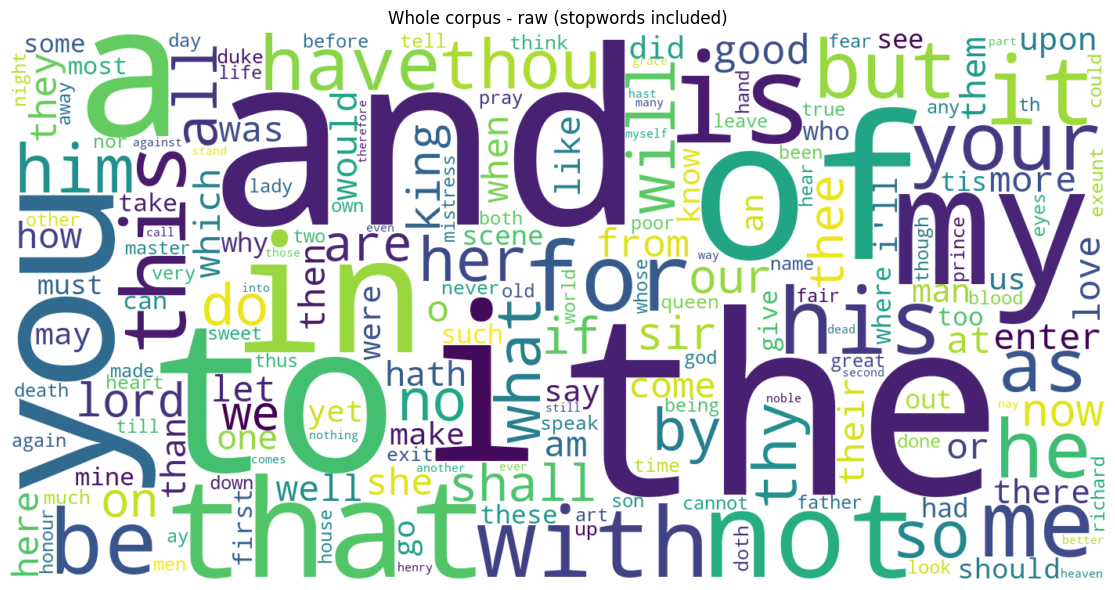

saved figure -> figures\wordcloud_corpus_no_stopwords.png


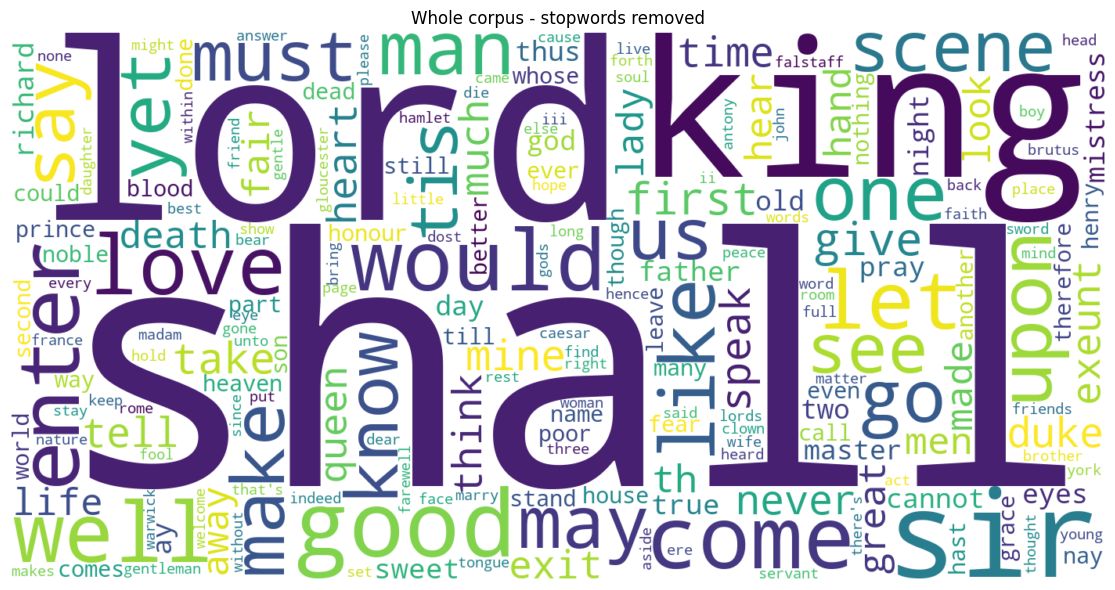

In [12]:
def make_cloud(counter, **kw):
    return WordCloud(width=1400, height=700, background_color="white", max_words=200,
                     colormap="viridis", random_state=SEED, **kw).generate_from_frequencies(counter)


cnt_raw = ngrams_full[1]
cnt_nostop = Counter({g[0]: c for g, c in ngrams_filt[1].items()})
cnt_raw = Counter({g[0]: c for g, c in cnt_raw.items()})

for cnt, ttl, fname in [(cnt_raw, "Whole corpus - raw (stopwords included)", "wordcloud_corpus_raw.png"),
                        (cnt_nostop, "Whole corpus - stopwords removed", "wordcloud_corpus_no_stopwords.png")]:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(make_cloud(cnt), interpolation="bilinear")
    ax.axis("off")
    ax.set_title(ttl)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()

saved figure -> figures\wordclouds_by_category.png


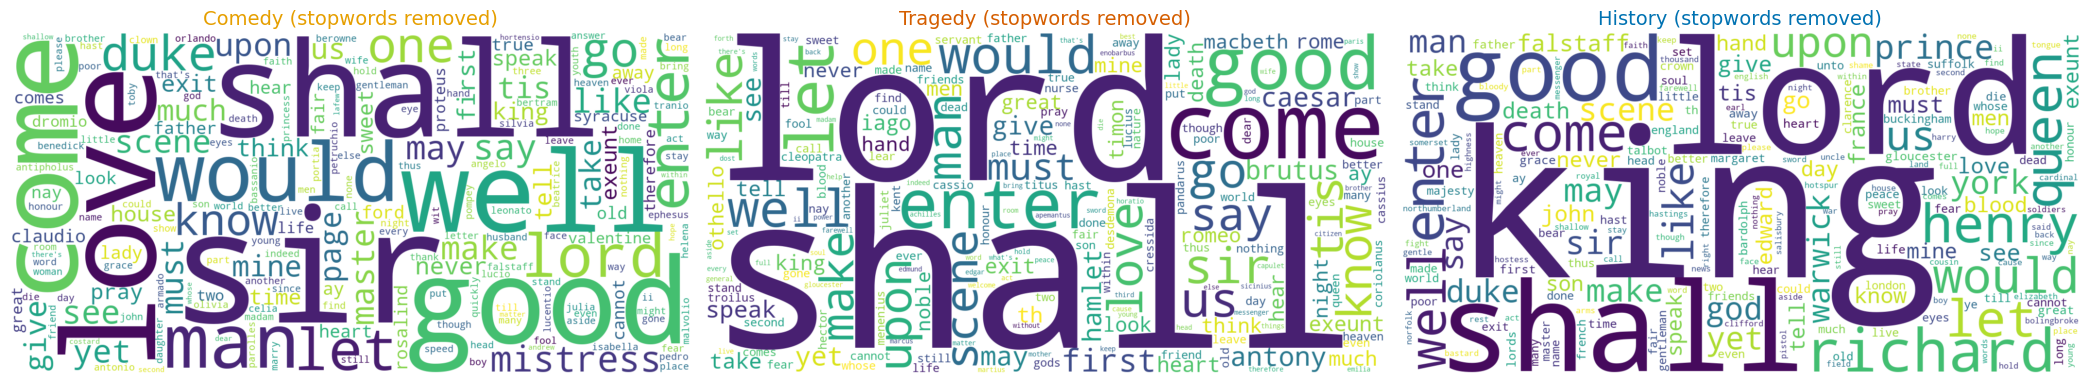

In [13]:
cat_counters = {c: Counter() for c in ("Comedy", "Tragedy", "History")}
for s, toks in tokens_by_slug.items():
    c = cat_of[s]
    if c in cat_counters:
        cat_counters[c].update(t for t in toks if t not in STOP_ALL)

fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
for ax, (c, cnt) in zip(axes, cat_counters.items()):
    ax.imshow(make_cloud(cnt), interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{c} (stopwords removed)", fontsize=14, color=CAT_COLORS[c])
plt.tight_layout()
save_fig(fig, "wordclouds_by_category.png")
plt.show()

The category clouds are dominated by shared vocabulary (*love, lord, good, man, ...*) plus play-specific character names. In the per-category panels, stopwords were removed, otherwise all three clouds would be nearly identical.

## 6. Distinctive Shakespearean words (vs WikiText-2)

We compare word frequencies in Shakespeare against **WikiText-2** (modern encyclopaedic English; train + validation + test used together as a bigger reference corpus) using the **log-odds ratio with an informative Dirichlet prior** (Monroe, Colaresi & Quinn, 2008, *"Fightin' Words"*). The prior for each word is its count in the two corpora combined, which shrinks the scores of rare words. For word *w*:

- δ = log[(y<sub>S</sub> + α<sub>w</sub>) / (n<sub>S</sub> + α<sub>0</sub> − y<sub>S</sub> − α<sub>w</sub>)] − log[(y<sub>W</sub> + α<sub>w</sub>) / (n<sub>W</sub> + α<sub>0</sub> − y<sub>W</sub> − α<sub>w</sub>)]
- variance ≈ 1/(y<sub>S</sub> + α<sub>w</sub>) + 1/(y<sub>W</sub> + α<sub>w</sub>), and the ranking uses the **z-score** δ / √variance.

WikiText-2 pre-tokenizes clitics (`wasn 't`, `game 's`); we glue them back before tokenizing so that Shakespeare's *don't* and Wikipedia's *don 't* are comparable.

In [14]:
# ---- load WikiText-2 (download once with Hugging Face datasets, then cache as text under data/baseline/)
if not BASELINE_DIR.exists():
    from datasets import load_dataset
    ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")      # a.k.a. wikitext-2-raw-v1
    BASELINE_DIR.mkdir(parents=True)
    for split_name in ds:
        (BASELINE_DIR / f"wikitext2_{split_name}.txt").write_text("\n".join(ds[split_name]["text"]), encoding="utf-8")
    print("downloaded WikiText-2 ->", BASELINE_DIR)

WIKI_CLITIC_RE = re.compile(r" '(s|t|re|ve|ll|d|m)\b", re.IGNORECASE)
wiki_counter = Counter()
for p in sorted(BASELINE_DIR.glob("wikitext2_*.txt")):
    for line in p.read_text(encoding="utf-8").splitlines():
        wiki_counter.update(tokenize(WIKI_CLITIC_RE.sub(r"'\1", line)))
print(f"WikiText-2: {sum(wiki_counter.values()):,} tokens, {len(wiki_counter):,} types   |   "
      f"Shakespeare: {N:,} tokens, {V:,} types")

WikiText-2: 2,052,424 tokens, 71,859 types   |   Shakespeare: 968,022 tokens, 26,909 types


In [15]:
def log_odds_dirichlet(c_i, c_j):
    prior = c_i + c_j                                    # informative prior = pooled counts
    n_i, n_j = sum(c_i.values()), sum(c_j.values())
    a0 = sum(prior.values())
    rows = []
    for w, a in prior.items():
        yi, yj = c_i.get(w, 0), c_j.get(w, 0)
        d = np.log((yi + a) / (n_i + a0 - yi - a)) - np.log((yj + a) / (n_j + a0 - yj - a))
        z = d / np.sqrt(1 / (yi + a) + 1 / (yj + a))
        rows.append((w, yi, yj, d, z))
    return pd.DataFrame(rows, columns=["word", "count_shakespeare", "count_wikitext", "log_odds", "z_score"])


lo = log_odds_dirichlet(corpus_counter, wiki_counter).sort_values("z_score", ascending=False).reset_index(drop=True)
lo.insert(0, "rank", lo.index + 1)

# How often does each word occur inside play *structure* (speaker tags, stage directions, ACT/SCENE headers)?
structural_counter = Counter()
for t in texts.values():
    for line in t.splitlines():
        part = structural_part(line)
        if part:
            structural_counter.update(tokenize(part))
lo["pct_in_structure"] = lo["word"].map(lambda w: round(100 * structural_counter[w] / max(corpus_counter[w], 1), 1))
lo["likely_name_or_stage_word"] = lo["pct_in_structure"] >= 25          # heuristic, see note below

# relative-frequency ratio (per-token rate in Shakespeare / rate in WikiText-2, add-0.5 smoothed)
n_w = sum(wiki_counter.values())
lo["rate_ratio"] = ((lo["count_shakespeare"] / N) / ((lo["count_wikitext"] + 0.5) / n_w)).round(1)
lo["is_archaic_candidate"] = ((lo["rate_ratio"] >= 100) & (lo["count_shakespeare"] >= 20)
                              & ~lo["likely_name_or_stage_word"])

keywords = lo.head(300).copy()
keywords[["log_odds", "z_score"]] = keywords[["log_odds", "z_score"]].round(3)
save_table(keywords, "archaic_keywords.csv")
display(keywords.head(30))
print(f"{keywords.head(30)['likely_name_or_stage_word'].sum()} of the top 30 are mostly names / stage words; "
      f"{keywords.head(30)['is_archaic_candidate'].sum()} of the top 30 are archaic candidates")

saved table  -> tables\archaic_keywords.csv


,rank,word,count_shakespeare,count_wikitext,log_odds,z_score,pct_in_structure,likely_name_or_stage_word,rate_ratio,is_archaic_candidate
0,1,i,22210,2509,0.791,103.877,2.4,False,18.8,False
1,2,you,14400,912,0.850,87.057,1.8,False,33.5,False
2,3,my,13204,497,0.884,85.190,0.9,False,56.3,False
3,4,me,8279,465,0.857,66.277,1.0,False,37.7,False
4,5,your,7065,208,0.893,62.624,1.2,False,71.8,False
5,6,thou,5866,7,0.934,58.438,1.1,False,1658.3,True
6,7,thy,4354,7,0.933,50.304,1.0,False,1230.9,True
7,8,will,5302,899,0.725,48.004,1.4,False,12.5,False
8,9,shall,3858,31,0.923,47.084,1.4,False,259.7,True
9,10,so,5478,1304,0.658,45.944,0.9,False,8.9,False


2 of the top 30 are mostly names / stage words; 5 of the top 30 are archaic candidates


saved figure -> figures\distinctive_words_top30_bar.png


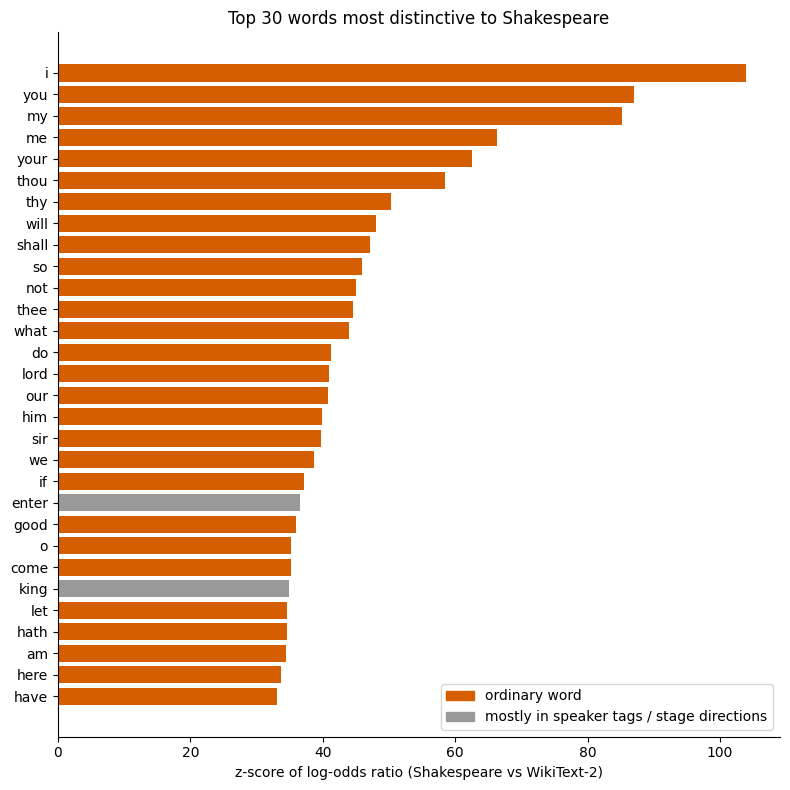

saved figure -> figures\distinctive_words_top30_wordcloud.png


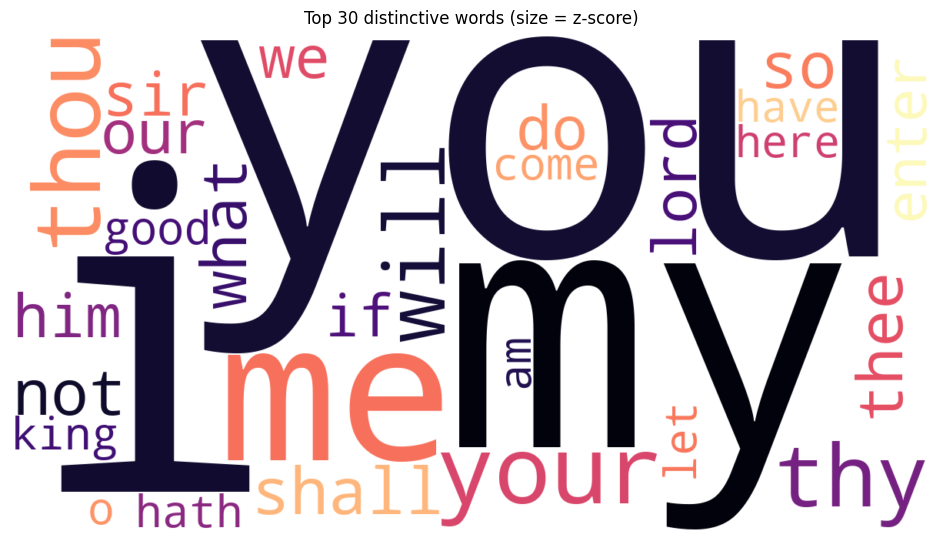

In [16]:
top30 = lo.head(30)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#999999" if f else "#D55E00" for f in top30["likely_name_or_stage_word"]]
ax.barh(top30["word"][::-1], top30["z_score"][::-1], color=colors[::-1])
ax.set_xlabel("z-score of log-odds ratio (Shakespeare vs WikiText-2)")
ax.set_title("Top 30 words most distinctive to Shakespeare")
ax.legend([plt.Rectangle((0, 0), 1, 1, color="#D55E00"), plt.Rectangle((0, 0), 1, 1, color="#999999")],
          ["ordinary word", "mostly in speaker tags / stage directions"], loc="lower right")
plt.tight_layout()
save_fig(fig, "distinctive_words_top30_bar.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
cloud = WordCloud(width=1200, height=650, background_color="white", colormap="magma", random_state=SEED)
ax.imshow(cloud.generate_from_frequencies(dict(zip(top30["word"], top30["z_score"]))), interpolation="bilinear")
ax.axis("off")
ax.set_title("Top 30 distinctive words (size = z-score)")
plt.tight_layout()
save_fig(fig, "distinctive_words_top30_wordcloud.png")
plt.show()

saved figure -> figures\distinctive_words_top30_excluding_names_bar.png


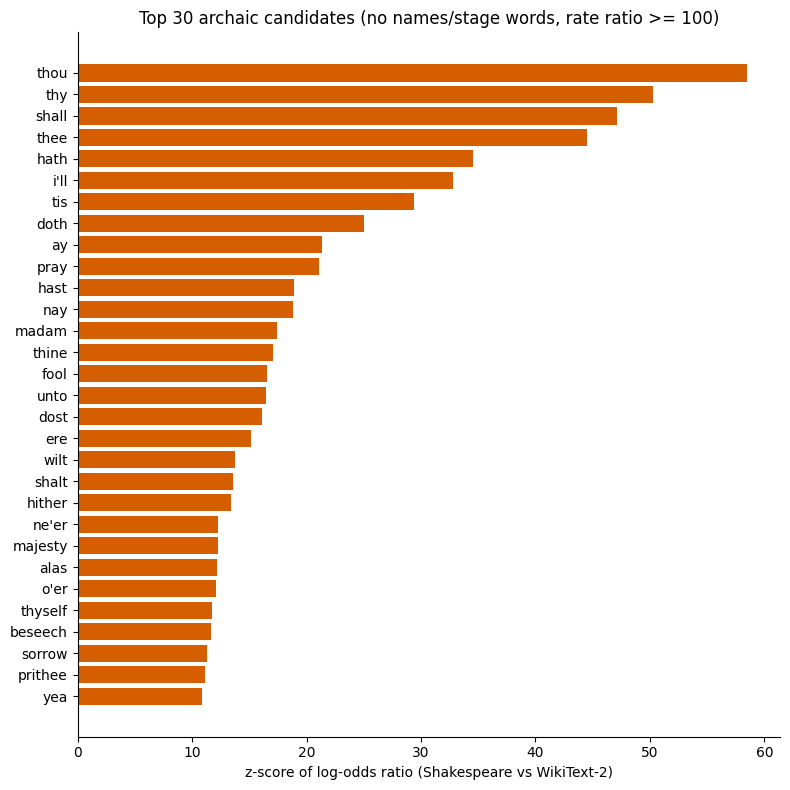

In [17]:
# Same ranking restricted to "archaic candidates": not a name/stage word AND at least 100x more frequent
# (per token) than in WikiText-2. Pronouns like "i"/"you" drop out; thou/thee/hath/doth-type words remain.
clean = lo[lo["is_archaic_candidate"]].head(30)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(clean["word"][::-1], clean["z_score"][::-1], color="#D55E00")
ax.set_xlabel("z-score of log-odds ratio (Shakespeare vs WikiText-2)")
ax.set_title("Top 30 archaic candidates (no names/stage words, rate ratio >= 100)")
plt.tight_layout()
save_fig(fig, "distinctive_words_top30_excluding_names_bar.png")
plt.show()

`tables/archaic_keywords.csv` stores the **top 300** words ranked by z-score, with extra columns to help filter them:
- `pct_in_structure` / `likely_name_or_stage_word` – share of the word's occurrences that sit inside speaker tags, stage directions or ACT/SCENE headers (flag = at least 25 %). Character names and *enter/exeunt* are caught this way.
- `rate_ratio` / `is_archaic_candidate` – how many times more frequent the word is (per token) in Shakespeare than in WikiText-2 (flag = at least 100× and ≥ 20 occurrences, and not a name/stage word).

The strict log-odds ranking is topped by very frequent function words (*i, you, my, thou, thy*): dialogue is full of first/second-person language, which encyclopaedic text is not. The z-score rewards *reliable* differences in frequent words, so for an "archaic words" evaluation list use the `is_archaic_candidate` rows. Both flags are heuristics.

## 7. Vocabulary coverage (OOV)

- **Train → test:** which share of test tokens would be unknown (`<UNK>`) to a model whose vocabulary is the full train vocabulary? (Validation shown too.)
- **WikiText-2 → Shakespeare:** how much of Shakespeare's text a modern-English vocabulary does not cover.

In [18]:
split_of_slug = dict(zip(split_df["slug"], split_df["split"]))
split_counters = {sp: Counter() for sp in ("train", "val", "test")}
for s, toks in tokens_by_slug.items():
    split_counters[split_of_slug[s]].update(toks)
train_vocab = set(split_counters["train"])


def oov_row(name, counter, vocab):
    tot = sum(counter.values())
    oov_tok = sum(c for w, c in counter.items() if w not in vocab)
    oov_types = sum(1 for w in counter if w not in vocab)
    return {"evaluated_set": name, "tokens": tot, "oov_tokens": oov_tok, "pct_oov_tokens": round(100 * oov_tok / tot, 2),
            "types": len(counter), "oov_types": oov_types, "pct_oov_types": round(100 * oov_types / len(counter), 2)}


oov_df = pd.DataFrame([
    oov_row("test vs train vocabulary", split_counters["test"], train_vocab),
    oov_row("val vs train vocabulary", split_counters["val"], train_vocab),
    oov_row("Shakespeare (all) vs WikiText-2 vocabulary", corpus_counter, set(wiki_counter)),
])
display(oov_df)
save_table(oov_df, "oov_coverage.csv")

test_oov = pd.DataFrame([(w, c) for w, c in split_counters["test"].most_common() if w not in train_vocab][:20], columns=["word", "count"])
shak_oov = pd.DataFrame([(w, c) for w, c in corpus_counter.most_common() if w not in wiki_counter][:20], columns=["word", "count"])
print("Most frequent test words unseen in train:")
display(test_oov.T)
print("Most frequent Shakespeare words absent from WikiText-2:")
display(shak_oov.T)
save_table(test_oov, "oov_top_test_words_not_in_train.csv")
save_table(shak_oov, "oov_top_shakespeare_words_not_in_wikitext.csv")

,evaluated_set,tokens,oov_tokens,pct_oov_tokens,types,oov_types,pct_oov_types
0,test vs train vocabulary,93104,3843,4.13,8670,1283,14.80
1,val vs train vocabulary,108958,3850,3.53,9185,1351,14.71
2,Shakespeare (all) vs WikiText-2 vocabulary,968022,60972,6.30,26909,13017,48.37


saved table  -> tables\oov_coverage.csv
Most frequent test words unseen in train:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
word,toby,enobarbus,prospero,olivia,viola,malvolio,charmian,cade,ariel,fabian,caliban,gonzalo,eros,miranda,trinculo,menas,alonso,alexandria,octavia,iras
count,206,154,147,145,139,128,106,97,92,74,71,66,64,64,62,53,53,45,44,43


Most frequent Shakespeare words absent from WikiText-2:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
word,exeunt,timon,hither,ne'er,alas,o'er,cassio,beseech,desdemona,palamon,dromio,proteus,antipholus,prithee,arcite,petruchio,bardolph,yea,menenius,benedick
count,1095,314,308,258,255,253,244,232,224,224,222,221,218,213,212,211,207,203,200,199


saved table  -> tables\oov_top_test_words_not_in_train.csv
saved table  -> tables\oov_top_shakespeare_words_not_in_wikitext.csv


Only a small share of test *tokens* is out of the train vocabulary, but a larger share of test *types* is, since the OOV words are mostly rare words and character names that belong to a single play (a consequence of splitting by work). Shakespeare vs WikiText-2 shows the gap between the two registers: a modern vocabulary would miss many of Shakespeare's frequent words, so training on modern text is not a substitute.

## 8. Raw-data issues (motivation for preprocessing)

Nothing is changed here; we only *measure* what in the raw files would hurt a next-word model if left untouched. All counts are over the 44 raw files.

In [19]:
CONTRACTIONS = {
    "'tis / 't-contractions ('twas, 'twere, ...)": re.compile(r"(?<![A-Za-z])'t(?:is|was|were|will|would)\b", re.I),
    "o'er": re.compile(r"\bo'er\b", re.I),
    "ne'er": re.compile(r"\bne'er\b", re.I),
    "e'er": re.compile(r"\be'er\b", re.I),
    "i' th' / i'th'": re.compile(r"\bi'\s*th\b'?", re.I),
    "th' + word (th'art, th'other, ...)": re.compile(r"\bth'\w+", re.I),
}

stats = {k: {"count": 0, "works": set(), "tokens": 0, "examples": []} for k in
         ["all-caps speaker tags", "stage directions (Enter/Exit/Exeunt/[...])", "ACT/SCENE headers",
          "underscore italics markup (_..._)", *CONTRACTIONS]}
speaker_counter = Counter()


def note(key, slug, line, n=1, tokens=0):
    s = stats[key]
    s["count"] += n
    s["works"].add(slug)
    s["tokens"] += tokens
    if len(s["examples"]) < 3 and line.strip() not in s["examples"]:
        s["examples"].append(line.strip())


for slug, text in texts.items():
    for line in text.splitlines():
        if HEADER_RE.match(line):
            note("ACT/SCENE headers", slug, line, tokens=len(tokenize(line)))
            continue
        m = SPEAKER_RE.match(line)
        if m:
            speaker_counter[m.group(1)] += 1
            note("all-caps speaker tags", slug, line, tokens=len(tokenize(m.group(1))))
        if STAGE_RE.match(line) or BRACKET_RE.search(line):
            note("stage directions (Enter/Exit/Exeunt/[...])", slug, line, tokens=len(tokenize(line)))
        if "_" in line:
            note("underscore italics markup (_..._)", slug, line, n=line.count("_") // 2 or 1)
        norm = normalize_apostrophes(line)
        for key, rx in CONTRACTIONS.items():
            hits = rx.findall(norm)
            if hits:
                note(key, slug, line, n=len(hits))

rows = []
for k, s in stats.items():
    rows.append({"issue": k, "occurrences": s["count"], "works_affected": len(s["works"]),
                 "tokens_involved": s["tokens"] or None,
                 "pct_of_all_tokens": round(100 * s["tokens"] / N, 2) if s["tokens"] else None,
                 "examples": " | ".join(s["examples"])})
issues_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 90)
display(issues_df)
save_table(issues_df, "raw_issues_summary.csv")

print("\nMost frequent speaker tags:")
spk = pd.DataFrame(speaker_counter.most_common(15), columns=["speaker_tag", "lines_spoken"])
display(spk.T)
save_table(spk, "raw_issues_top_speaker_tags.csv")
print(f"distinct speaker tags: {len(speaker_counter):,}")

,issue,occurrences,works_affected,tokens_involved,pct_of_all_tokens,examples
0,all-caps speaker tags,31745,40,36515.0,3.77,KING OF FRANCE. | THE DUKE OF FLORENCE. | COUNTESS.
1,stage directions (Enter/Exit/Exeunt/[...]),6352,38,28626.0,2.96,"Enter Bertram, the Countess of Rossillon, Helena, and Lafew, all in | [_Exit Countess...."
2,ACT/SCENE headers,1191,38,6294.0,0.65,ACT I | ACT II | ACT III
3,underscore italics markup (_..._),5063,38,NaN,NaN,"[_Exit Countess._] | [_To Helena._] Be comfortable to my mother, your mistress, and ma..."
4,"'tis / 't-contractions ('twas, 'twere, ...)",1925,43,NaN,NaN,"My body is the frame wherein ’tis held, | ’Tis not enough that through the cloud thou ..."
5,o'er,253,42,NaN,NaN,Beauty o’er-snowed and bareness every where: | And sable curls all silvered o’er with ...
6,ne'er,258,43,NaN,NaN,Such heavenly touches ne’er touched earthly faces. | For I must ne’er love him whom th...
7,e'er,89,30,NaN,NaN,deliver’d in the most bitter touch of sorrow that e’er I heard virgin | [_Aside._] Thi...
8,i' th' / i'th',231,24,NaN,NaN,"Looks bleak i’ th’ cold wind: withal, full oft we see | Did show ourselves i’ th’ fiel..."
9,"th' + word (th'art, th'other, ...)",93,13,NaN,NaN,"Th’ambition in my love thus plagues itself: | Confess it, t’one to th’other; and thine..."


saved table  -> tables\raw_issues_summary.csv

Most frequent speaker tags:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
speaker_tag,FALSTAFF,KING,DUKE,HAMLET,KING HENRY,BRUTUS,RICHARD,OTHELLO,IAGO,CLOWN,PRINCE,ANTONY,GLOUCESTER,KING RICHARD,TIMON
lines_spoken,472,455,369,358,352,283,280,273,272,258,258,254,249,228,210


saved table  -> tables\raw_issues_top_speaker_tags.csv
distinct speaker tags: 973


In [20]:
# curly vs straight punctuation in the raw files
all_text = "".join(texts.values())
quote_counts = pd.DataFrame({
    "character": ["\u2019 (curly apostrophe)", "' (straight apostrophe)", "\u2018 (curly open single quote)",
                  "\u201c (curly open double quote)", "\u201d (curly close double quote)", "\" (straight double quote)"],
    "count": [all_text.count("\u2019"), all_text.count("'"), all_text.count("\u2018"),
              all_text.count("\u201c"), all_text.count("\u201d"), all_text.count('"')],
})
display(quote_counts)
save_table(quote_counts, "raw_issues_curly_vs_straight_quotes.csv")

# without normalisation the same word is split into two types
poss = Counter(re.findall(r"[A-Za-z]+[\u2019'][a-z]+", all_text))
forms = {}
for w, c in poss.items():
    forms.setdefault(w.replace("\u2019", "'").lower(), set()).add("curly" if "\u2019" in w else "straight")
both = [k for k, v in forms.items() if len(v) == 2]
print(f"Words appearing with BOTH apostrophe styles: {len(both)} (e.g. {both[:5]})")
raw_vocab = len(set(re.findall(r"[A-Za-z]+(?:[\u2019'][A-Za-z]+)*", all_text.lower())))
print(f"Vocabulary without apostrophe normalisation: {raw_vocab:,}  vs  with: {V:,}")

,character,count
0,’ (curly apostrophe),26332
1,' (straight apostrophe),1
2,‘ (curly open single quote),372
3,“ (curly open double quote),1232
4,” (curly close double quote),1059
5,""" (straight double quote)",0


saved table  -> tables\raw_issues_curly_vs_straight_quotes.csv


Words appearing with BOTH apostrophe styles: 0 (e.g. [])

Vocabulary without apostrophe normalisation: 26,909  vs  with: 26,909


In [21]:
# Which of these raw artefacts appear in the top-20 unigram lists?
rows = []
for view, counters in [("with stopwords", ngrams_full), ("without stopwords", ngrams_filt)]:
    for rank, (g, c) in enumerate(counters[1].most_common(20), 1):
        w = g[0]
        pct = round(100 * structural_counter[w] / c, 1)
        rows.append({"view": view, "rank": rank, "word": w, "count": c,
                     "pct_in_tags_stage_headers": pct, "stage_keyword": w in STAGE_WORDS,
                     "contains_apostrophe": "'" in w})
top_check = pd.DataFrame(rows)
top_check["flagged"] = (top_check["pct_in_tags_stage_headers"] >= 10) | top_check["stage_keyword"] | top_check["contains_apostrophe"]
flagged = top_check[top_check["flagged"]]
display(flagged)
save_table(top_check, "raw_issues_artefacts_in_top20_unigrams.csv")
print("Flagged words per view:")
print(flagged.groupby("view")["word"].apply(list).to_string())

,view,rank,word,count,pct_in_tags_stage_headers,stage_keyword,contains_apostrophe,flagged
21,without stopwords,2,lord,3134,12.1,False,False,True
22,without stopwords,3,king,3015,49.3,False,False,True
23,without stopwords,4,sir,2998,12.9,False,False,True
27,without stopwords,8,enter,2487,87.8,True,False,True


saved table  -> tables\raw_issues_artefacts_in_top20_unigrams.csv
Flagged words per view:
view
without stopwords    [lord, king, sir, enter]


## Summary of key findings

1. **Split:** works are split whole into train / val / test = 36 / 4 / 4 works, 762,312 / 108,313 / 92,615 words (79.1 % / 11.2 % / 9.6 %); val and test each contain one Comedy, Tragedy, History and Romance, and all Poetry is in train.
2. **Size:** 44 works, 963,240 whitespace-separated words (968,022 regex tokens), about 21.9k words per work; Tragedy, History and Comedy are ~27-29 % of the words each, Romance 12 %, Poetry only 5 %.
3. **Vocabulary:** 26,909 word types, type-token ratio 0.028, and the rank-frequency curve is close to Zipfian (fitted exponent ~1.04).
4. **Sparsity of words:** 37.8 % of word types occur only once (hapax), yet they are just 1.05 % of the running text, while the 13.6 % of types occurring more than 20 times cover 91.2 % of all tokens - a vocabulary cap with an `<UNK>` token loses very little.
5. **Sparsity of n-grams:** 74.3 % of bigram types, 91.5 % of trigram types and 97.8 % of 4-gram types occur exactly once, so count-based n-gram models need smoothing/back-off, and long contexts will rarely have been seen in training.
6. **Lines:** the average line has 6.3 words (median 7, max 20), reflecting verse; a line-based model input would see very short sequences.
7. **Frequent n-grams:** with stopwords the top n-grams are function-word phrases (*i am, my lord, in the, i pray you*); without stopwords they are dominated by play structure (*king henry, exeunt scene, act iii scene*), and *enter* is in the top-20 unigrams.
8. **Distinctive words:** vs WikiText-2 the log-odds ranking is led by pronouns and address forms (*i, you, my, thou, thy, thee, lord, sir*); the stricter `is_archaic_candidate` list in `tables/archaic_keywords.csv` isolates genuinely archaic words (*thou, thy, thee, hath, doth, hast, nay, prithee, ne'er, o'er*).
9. **Coverage:** 4.1 % of test tokens (14.8 % of test types) are unseen in the train vocabulary, mostly character names of the held-out plays (*toby, prospero, olivia, ...*); against WikiText-2, 6.3 % of Shakespeare tokens and 48 % of its types are out of vocabulary.
10. **Raw-data issues:** speaker tags (31,745 lines, 3.8 % of tokens), stage directions (6,352 lines, 3.0 %), ACT/SCENE headers (0.65 %), ~5,000 `_italic_` markup spans and ~2,850 archaic contractions (*'tis, o'er, ne'er, i' th'*) are all still in the text; apostrophes are consistently curly (26,332 vs 1 straight), so they must be normalised before mixing with other corpora - these are the targets of the preprocessing phase.